## Make scatter plots of gridcells within each biome, for each month: Chl vs SST

### Model and Observations

In [1]:
import os
from glob import glob
from collections import OrderedDict
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import pop_tools 
from statistics import mean
from matplotlib import style
import matplotlib
from scipy import stats

### Get CESM model grid info

In [2]:
### First, get the pop grid information, so we have lon, lat
ds_grid = pop_tools.get_grid('POP_gx1v7')
lats = ds_grid.TLAT
lons = ds_grid.TLONG

### Read in biomes 

In [3]:
### Read in biomes for model
ds_biome_cesm = xr.open_dataset('CESM2_biomes.nc')

In [4]:
### Read in biomes for obs
ds_biome_obs = xr.open_dataset('Obs_biomes.nc')

### Read in CESM SST and Chl

In [5]:
ds_clim_cesm = xr.open_dataset('CESM_mon_clims.nc')

In [6]:
ds_clim_obs = xr.open_dataset('Obs4biomes.nc')

### Make a colormap for the figures

In [7]:
from matplotlib.colors import ListedColormap

In [8]:
# colors = ['lightcoral','red','darkorange','gold','lightgreen','green',
#           'darkgreen','darkturquoise','dodgerblue','blue','darkviolet','magenta','hotpink']

#cmap_biome = matplotlib.colors.LinearSegmentedColormap.from_list('biomes', colors)
#cmap_biome = ListedColormap(colors)

biome_names = ['NH_ICE','NPac_SPSS','NAtl_SPSS',
          'NH_STSS','NH_STPS','IND_STPS','WPac_EQ',
          'EPac_EQ','Atl_EQ','SH_ICE','SH_SPSS','SH_STSS',
          'SH_STPS']

unique_cats, cat_codes = np.unique(biome_names, return_inverse=True)
num_cats = len(unique_cats)

# 2. Extract a discrete N-bin version of a qualitative colormap
cmap_biome = plt.get_cmap('Paired', num_cats)

# cmap_biome = matplotlib.colors.LinearSegmentedColormap.from_list('biomes', colors, N=13)

### Now make a loop that loops over each month

In [9]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

In [10]:
%%time

chl_vals_mon_dict_cesm = {}
sst_vals_mon_dict_cesm = {}
biome_vals_mon_dict_cesm = {}

chl_vals_mon_dict_obs = {}
sst_vals_mon_dict_obs = {}
biome_vals_mon_dict_obs = {}

i = 0

for m in months:

    print(m)
    
    ### first do CESM ###############################
    chl_vals = []
    sst_vals = []
    biome_vals = []
    
    for x in np.arange(0,len(ds_grid.nlon)-1,1):
        for y in np.arange(0,len(ds_grid.nlat)-1,1):
    
            #print(y)
    
            chl_val = ds_clim_cesm.Chl.isel(month=i)[y,x].values
            sst_val = ds_clim_cesm.TEMP.isel(month=i)[y,x].values
            biome_val = ds_biome_cesm.biome[y,x].values
    
            if np.isnan(chl_val):
                continue
            if np.isnan(sst_val):
                continue
            if np.isnan(biome_val):
                continue
    
            chl_vals.append(float(chl_val))
            sst_vals.append(float(sst_val))
            biome_vals.append(float(biome_val))

    chl_vals_cesm = xr.DataArray(chl_vals)
    sst_vals_cesm = xr.DataArray(sst_vals)
    biome_vals_cesm = xr.DataArray(biome_vals)

    chl_vals_mon_dict_cesm[m] = chl_vals_cesm
    sst_vals_mon_dict_cesm[m] = sst_vals_cesm
    biome_vals_mon_dict_cesm[m] = biome_vals_cesm

    print('did cesm')

    ### Now do OBS ###############################
    
    chl_vals = []
    sst_vals = []
    biome_vals = []
    
    for x in np.arange(0,len(ds_clim_obs.lon)-1,1):
        for y in np.arange(0,len(ds_clim_obs.lat)-1,1):
    
            #print(y)
    
            chl_val = ds_clim_obs.Chl.isel(month=i)[y,x].values
            sst_val = ds_clim_obs.SST.isel(month=i)[y,x].values
            biome_val = ds_biome_obs.biome[y,x].values
    
            if np.isnan(chl_val):
                continue
            if np.isnan(sst_val):
                continue
            if np.isnan(biome_val):
                continue
    
            chl_vals.append(float(chl_val))
            sst_vals.append(float(sst_val))
            biome_vals.append(float(biome_val))

    chl_vals_obs = xr.DataArray(chl_vals)
    sst_vals_obs = xr.DataArray(sst_vals)
    biome_vals_obs = xr.DataArray(biome_vals)

    chl_vals_mon_dict_obs[m] = chl_vals_obs
    sst_vals_mon_dict_obs[m] = sst_vals_obs
    biome_vals_mon_dict_obs[m] = biome_vals_obs

    print('did obs')
    
    i = i + 1

Jan
did cesm
did obs
Feb
did cesm
did obs
Mar
did cesm
did obs
Apr
did cesm
did obs
May
did cesm
did obs
Jun
did cesm
did obs
Jul
did cesm
did obs
Aug
did cesm
did obs
Sep
did cesm
did obs
Oct
did cesm
did obs
Nov
did cesm
did obs
Dec
did cesm
did obs
CPU times: user 29min 53s, sys: 13.1 s, total: 30min 7s
Wall time: 30min 10s


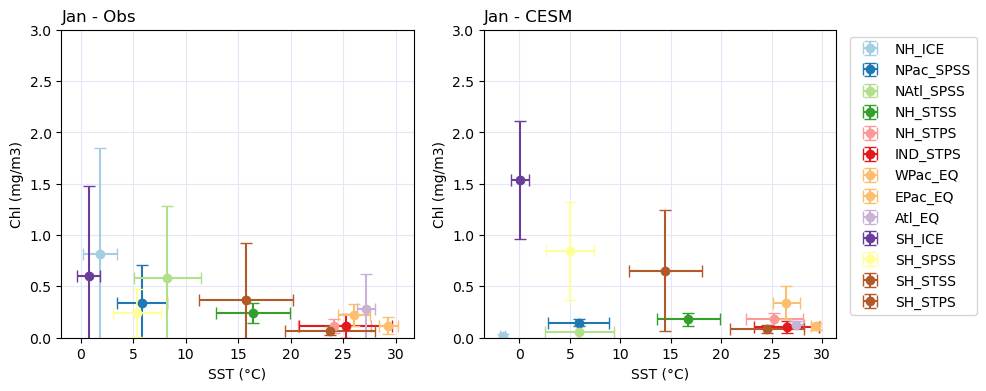

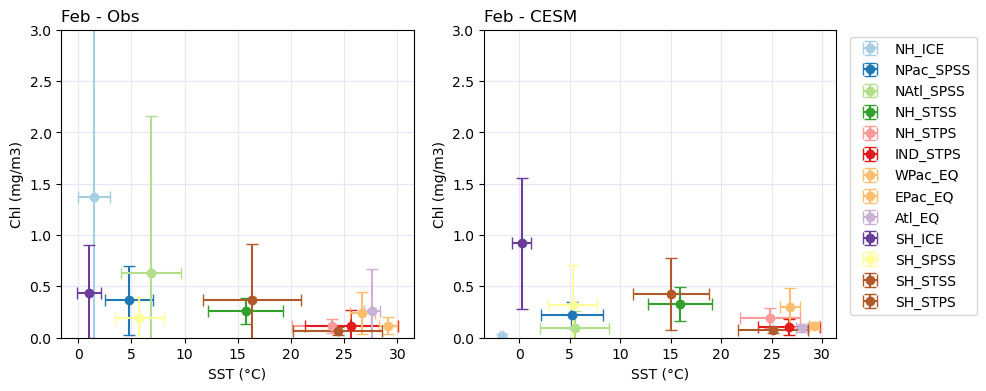

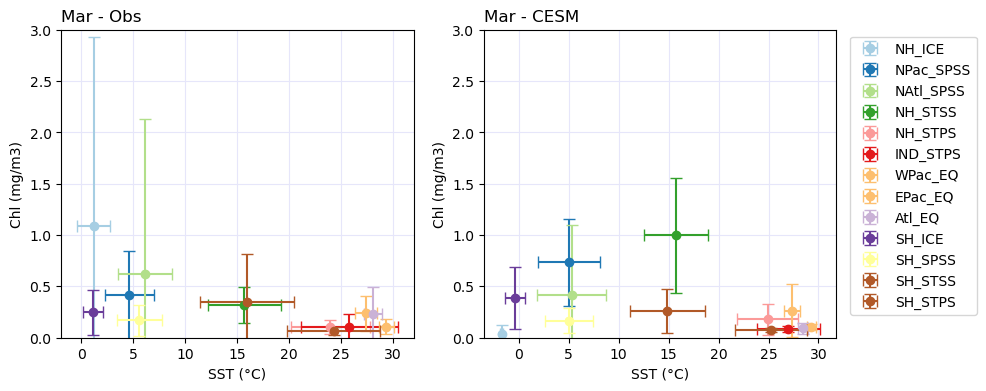

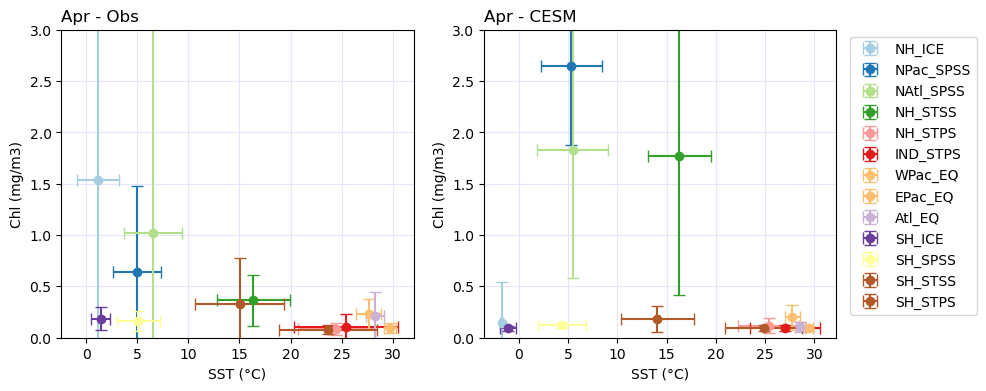

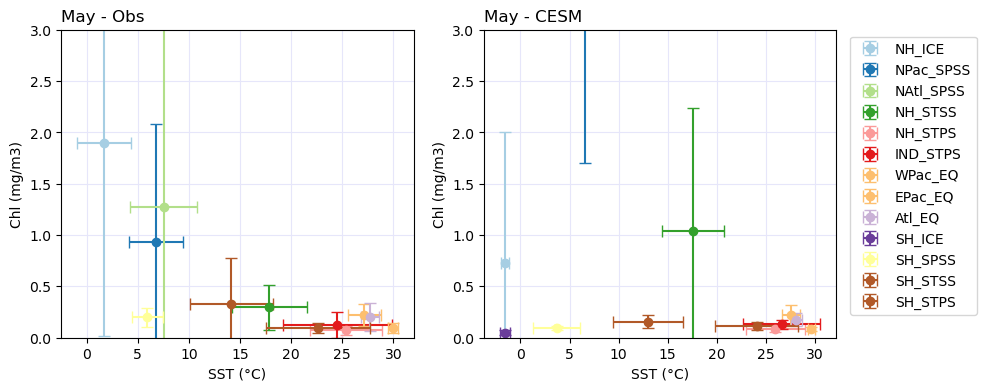

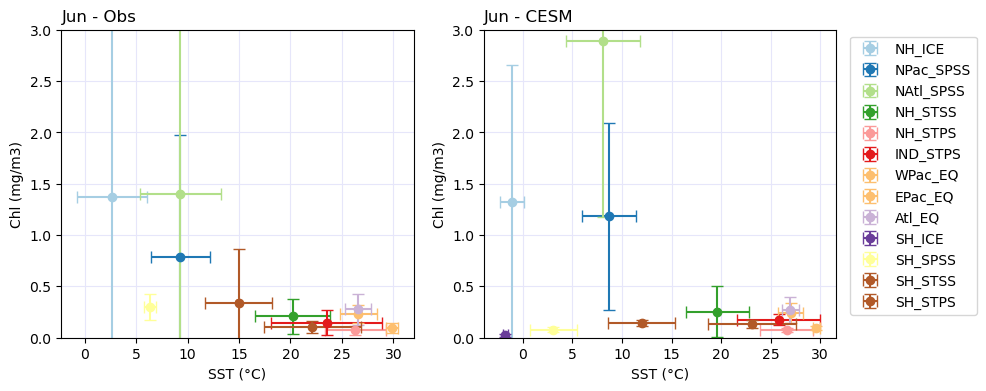

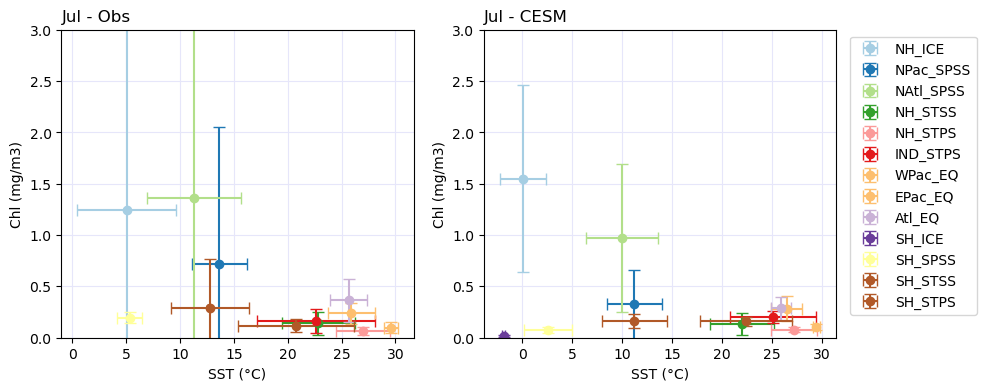

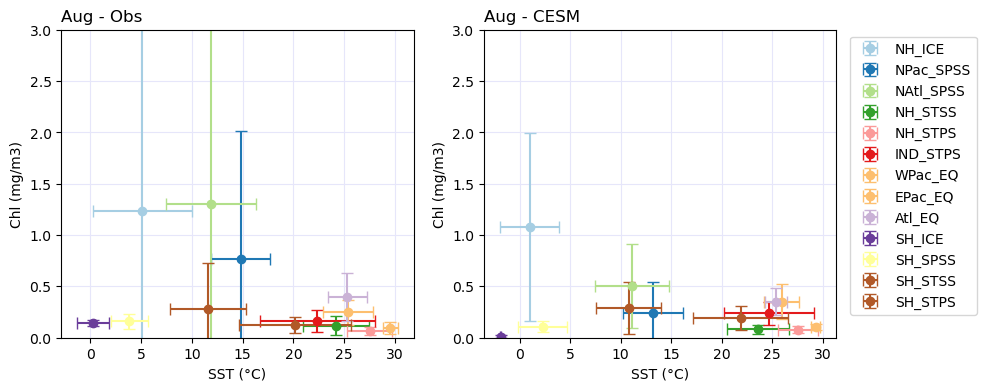

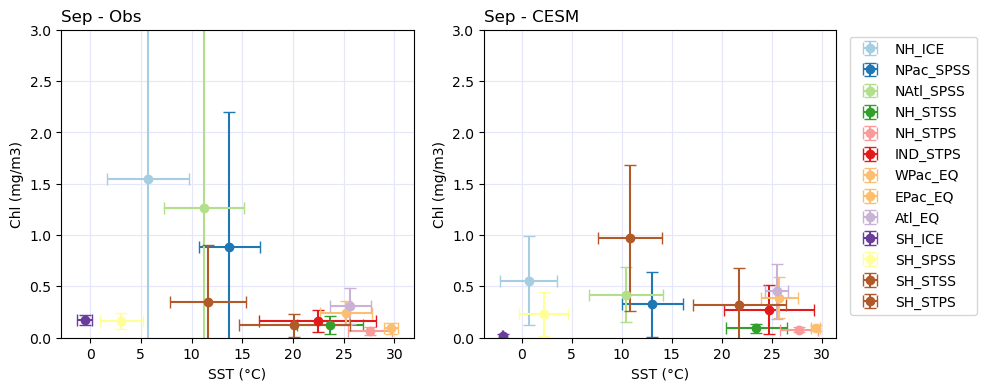

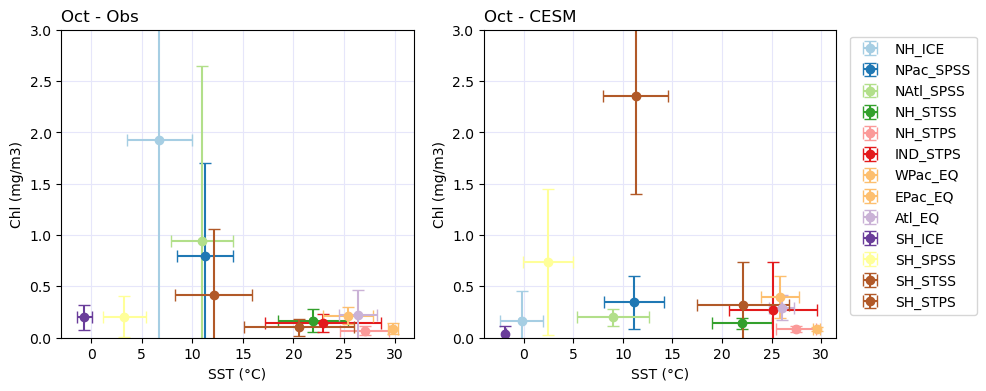

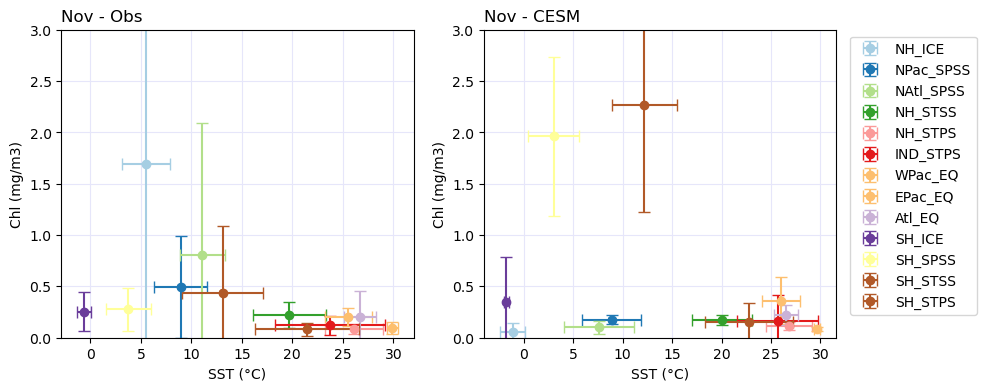

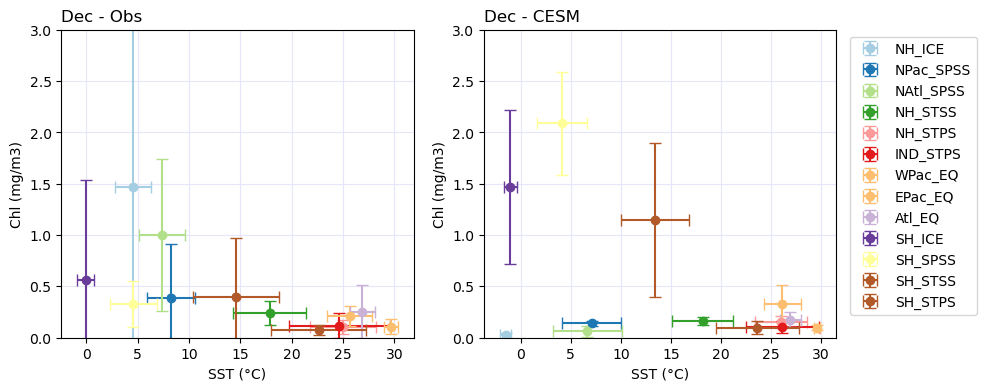

In [14]:

for m in months:

    fig = plt.figure(figsize=(10,4))
    
    ax = fig.add_subplot(1,2,1)
    ax.set_title(m+' - Obs', loc='left')
    xvals=np.full((13),0,dtype=np.float16)
    yvals=np.full((13),0,dtype=np.float16)
    bvals=np.full((13),0,dtype=int)
    for biome in np.arange(1,14,1):
        x = sst_vals_mon_dict_obs[m].where(biome_vals_mon_dict_obs[m]==biome).mean(dim='dim_0')
        y = chl_vals_mon_dict_obs[m].where(biome_vals_mon_dict_obs[m]==biome).mean(dim='dim_0')
        x_err = sst_vals_mon_dict_obs[m].where(biome_vals_mon_dict_obs[m]==biome).std(dim='dim_0')
        y_err = chl_vals_mon_dict_obs[m].where(biome_vals_mon_dict_obs[m]==biome).std(dim='dim_0')
        ax.errorbar(x, y, xerr=x_err, yerr=y_err, 
            fmt='o',
            color=cmap_biome.colors[biome-1], #colors[biome-1],
            capsize=4,
            label=biome_names[biome-1])
        xvals[biome-1] = x.values
        yvals[biome-1] = y.values
        bvals[biome-1] = biome
    sc = ax.scatter(xvals, yvals, c=bvals, cmap=cmap_biome, s=20)
    #ax.legend(bbox_to_anchor=(1.02, 1),loc='upper left')
    ax.xaxis.grid(True, which='major',color='lavender')
    ax.yaxis.grid(True, which='major',color='lavender');
    ax.set_xlabel('SST (°C)')
    ax.set_ylabel('Chl (mg/m3)')
    ax.set_ylim(0,3)
    
    ax = fig.add_subplot(1,2,2)
    ax.set_title(m+' - CESM', loc='left')
    xvals=np.full((13),0,dtype=np.float16)
    yvals=np.full((13),0,dtype=np.float16)
    bvals=np.full((13),0,dtype=int)
    for biome in np.arange(1,14,1):
        x = sst_vals_mon_dict_cesm[m].where(biome_vals_mon_dict_cesm[m]==biome).mean(dim='dim_0')
        y = chl_vals_mon_dict_cesm[m].where(biome_vals_mon_dict_cesm[m]==biome).mean(dim='dim_0')
        x_err = sst_vals_mon_dict_cesm[m].where(biome_vals_mon_dict_cesm[m]==biome).std(dim='dim_0')
        y_err = chl_vals_mon_dict_cesm[m].where(biome_vals_mon_dict_cesm[m]==biome).std(dim='dim_0')
        ax.errorbar(x, y, xerr=x_err, yerr=y_err, 
            fmt='o',
            color=cmap_biome.colors[biome-1], #colors[biome-1],
            capsize=4,
            label=biome_names[biome-1])
        xvals[biome-1] = x.values
        yvals[biome-1] = y.values
        bvals[biome-1] = biome
    sc = ax.scatter(xvals, yvals, c=bvals, cmap=cmap_biome, s=20)
    ax.legend(bbox_to_anchor=(1.02, 1),loc='upper left')
    ax.xaxis.grid(True, which='major',color='lavender')
    ax.yaxis.grid(True, which='major',color='lavender');
    ax.set_xlabel('SST (°C)')
    ax.set_ylabel('Chl (mg/m3)')
    ax.set_ylim(0,3);

    plt.show()

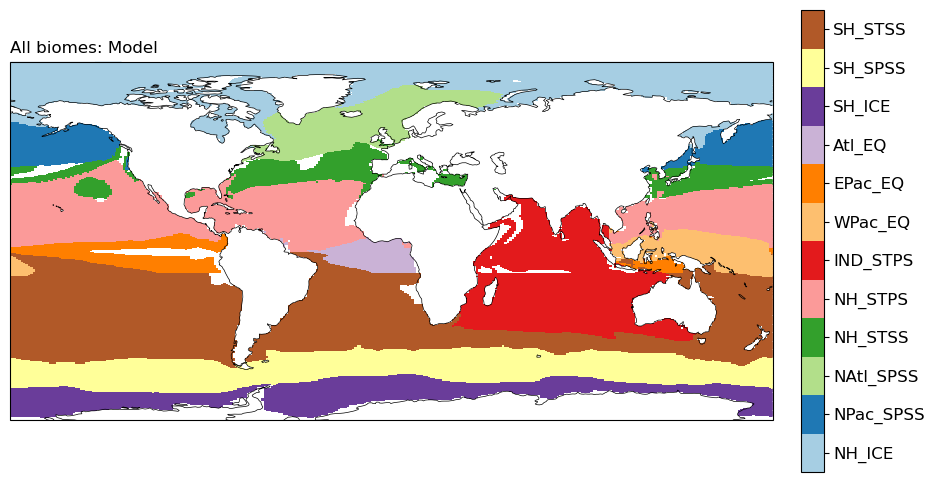

In [15]:
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
ax.coastlines('110m',linewidth=0.5)
ax.set_title('All biomes: Model', fontsize=12, loc='left')
pc1=ax.pcolormesh(lons, lats, ds_biome_cesm.biome, cmap='Paired',
                  transform=ccrs.PlateCarree())
#pci=ax.contourf(lons, lats, all_biomes.where(all_biomes==0),levels=[0,0.99],transform=ccrs.PlateCarree(),hatches=['//'],colors='none')

cbar = fig.colorbar(pc1, ticks=np.arange(1.5,14,1), pad=0.03)
cbar.ax.set_yticklabels(biome_names, fontsize=12) ;

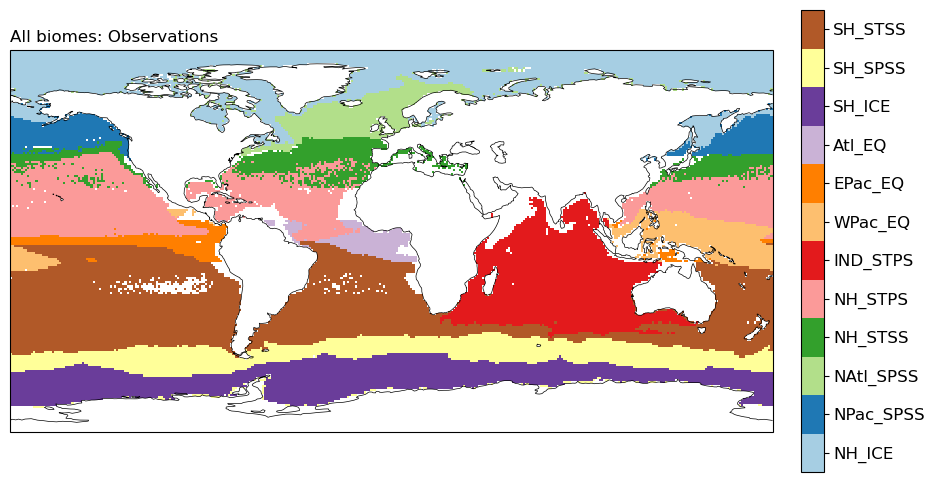

In [16]:
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
ax.coastlines('110m',linewidth=0.5)
ax.set_title('All biomes: Observations', fontsize=12, loc='left')
pc1=ax.pcolormesh(ds_biome_obs.lon, ds_biome_obs.lat, ds_biome_obs.biome, cmap='Paired',
                  transform=ccrs.PlateCarree())
#pci=ax.contourf(lons, lats, all_biomes.where(all_biomes==0),levels=[0,0.99],transform=ccrs.PlateCarree(),hatches=['//'],colors='none')

cbar = fig.colorbar(pc1, ticks=np.arange(1.5,14,1), pad=0.03)
cbar.ax.set_yticklabels(biome_names, fontsize=12) ;